# 02 — Exploratory Data Analysis
**ReadmitScope US**

We explore the **Excess Readmission Ratio (ERR)** = predicted ÷ expected readmission
rate. **ERR > 1 means a hospital readmits *more* than expected** for its case mix.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
ORANGE, DARK, MUTED = "#FF8000", "#0D0D0D", "#9CA3AF"
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "font.size": 10})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "hrrp_raw.csv"
PROC = ROOT / "data" / "processed" / "hrrp_reported.csv"

In [2]:
df = pd.read_csv(PROC, dtype={'facility_id':str})
print(len(df), 'reported measures across', df['facility_id'].nunique(), 'hospitals')

11720 reported measures across 2833 hospitals


## 1. How is ERR distributed nationally?
ERR is centered near 1.0 by construction. The question is the *spread* and how many hospitals sit above 1.

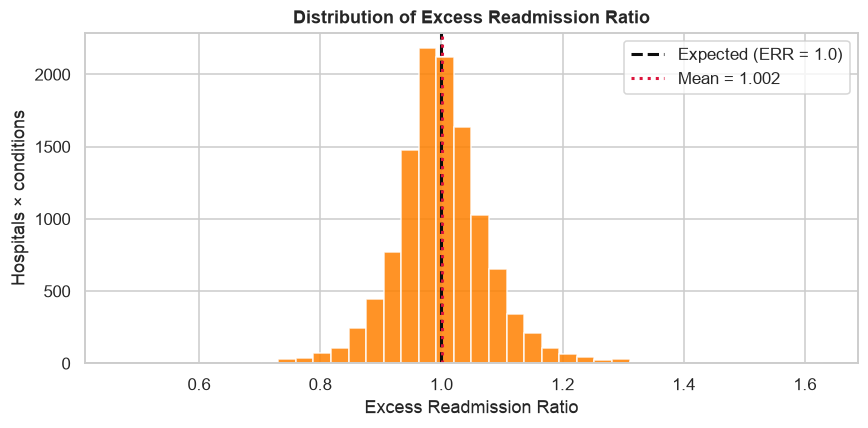

48.1% of reported measures are worse than expected (ERR>1)


In [3]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(df['err'], bins=40, color=ORANGE, edgecolor='white', alpha=0.85)
ax.axvline(1.0, color=DARK, ls='--', lw=2, label='Expected (ERR = 1.0)')
ax.axvline(df['err'].mean(), color='crimson', ls=':', lw=2, label=f"Mean = {df['err'].mean():.3f}")
ax.set_xlabel('Excess Readmission Ratio'); ax.set_ylabel('Hospitals × conditions')
ax.set_title('Distribution of Excess Readmission Ratio'); ax.legend()
plt.tight_layout(); plt.show()
print(f"{(df['err']>1).mean()*100:.1f}% of reported measures are worse than expected (ERR>1)")

**Read:** roughly symmetric around 1.0 but with a slightly heavier right tail — a minority of hospitals readmit *far* above expected (ERR up to ~1.6), while almost half exceed the benchmark.

## 2. Which conditions perform worst?

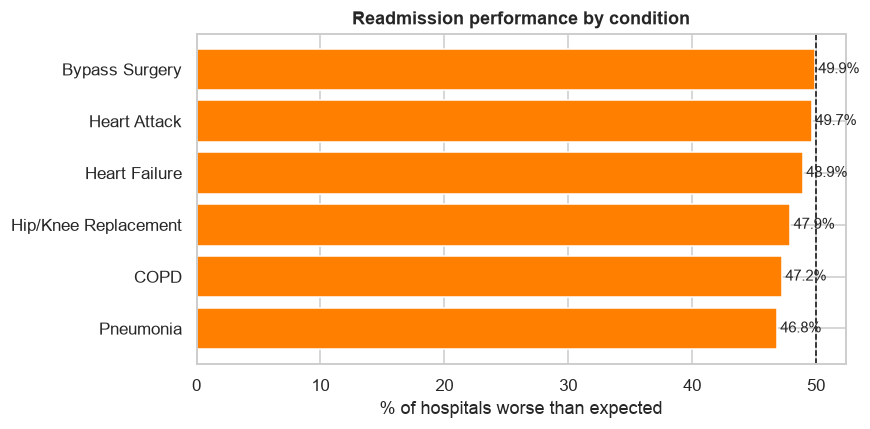

,mean_err,pct_worse,n
condition,,,
Bypass Surgery,1.002,49.886,878
Heart Attack,1.002,49.654,1736
Heart Failure,1.001,48.913,2621
Hip/Knee Replacement,1.004,47.892,1447
COPD,1.001,47.223,2323
Pneumonia,1.001,46.814,2715


In [4]:
by_cond = (df.groupby('condition')
             .agg(mean_err=('err','mean'),
                  pct_worse=('err', lambda s:(s>1).mean()*100),
                  n=('err','size'))
             .sort_values('pct_worse', ascending=False))
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(by_cond.index, by_cond['pct_worse'], color=ORANGE)
ax.axvline(50, color=DARK, ls='--', lw=1)
ax.set_xlabel('% of hospitals worse than expected'); ax.set_title('Readmission performance by condition')
ax.invert_yaxis()
for b,v in zip(bars, by_cond['pct_worse']): ax.text(v+0.3, b.get_y()+b.get_height()/2, f"{v:.1f}%", va='center')
plt.tight_layout(); plt.show()
by_cond.round(3)

**Read:** surgical/cardiac measures (Bypass surgery, Heart attack) have the highest share of worse-than-expected hospitals; pneumonia the lowest. The spread across conditions is modest, suggesting readmissions are a *systemic* challenge rather than isolated to one service line.

## 3. Does hospital volume relate to readmission performance?

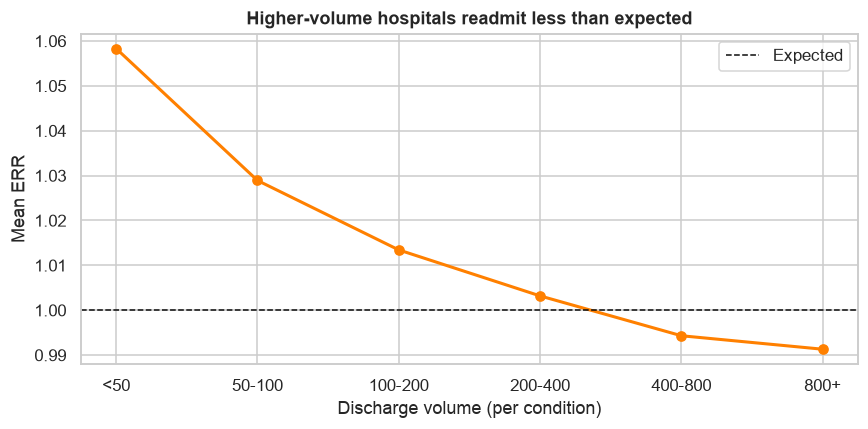

,mean_err,pct_worse,n
bin,,,
<50,1.058,98.958,96
50-100,1.029,71.487,1231
100-200,1.013,53.450,2623
200-400,1.003,48.963,2363
400-800,0.994,45.475,1337
800+,0.991,44.703,387


In [5]:
vol = df.dropna(subset=['discharges']).copy()
bins=[0,50,100,200,400,800,np.inf]; labels=['<50','50-100','100-200','200-400','400-800','800+']
vol['bin']=pd.cut(vol['discharges'],bins=bins,labels=labels,right=False)
g = vol.groupby('bin', observed=True).agg(mean_err=('err','mean'), pct_worse=('err',lambda s:(s>1).mean()*100), n=('err','size'))
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(g.index.astype(str), g['mean_err'], marker='o', color=ORANGE, lw=2)
ax.axhline(1.0, color=DARK, ls='--', lw=1, label='Expected')
ax.set_ylabel('Mean ERR'); ax.set_xlabel('Discharge volume (per condition)')
ax.set_title('Higher-volume hospitals readmit less than expected'); ax.legend()
plt.tight_layout(); plt.show()
g.round(3)

**Read:** a clear, monotonic gradient — the lowest-volume hospitals average well above 1.0 while the highest-volume average below 1.0. Consistent with a *volume–outcome* relationship (practice effects, resources). ⚠ Caveat: suppressed rows skew small, so the very-low-volume bin is a selected sample.

## 4. Geographic spread

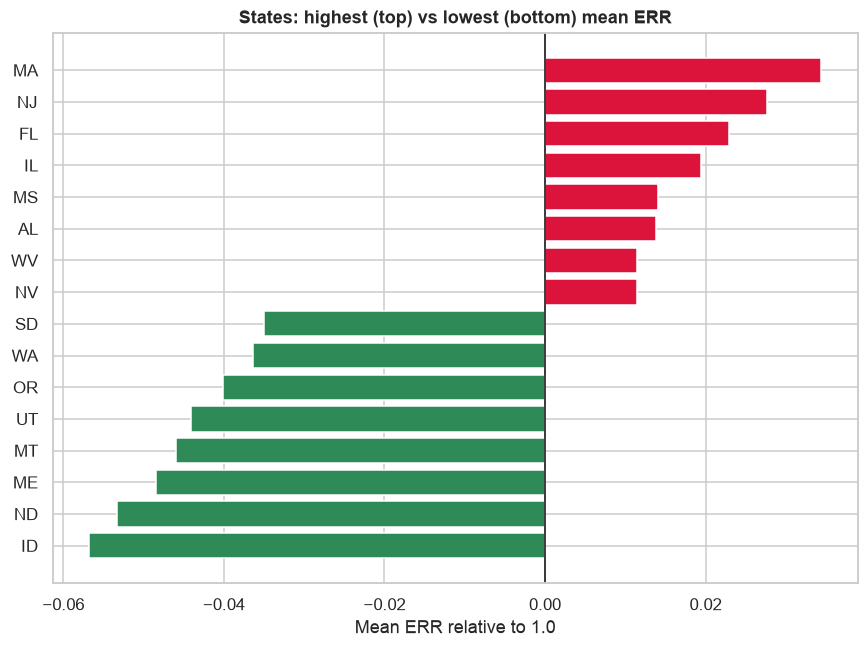

,mean_err,pct_worse,n
state,,,
MA,1.034,62.500,52
NJ,1.028,65.441,61
FL,1.023,57.458,164
IL,1.019,57.841,109
MS,1.014,61.081,50


In [6]:
by_state = (df.groupby('state').agg(mean_err=('err','mean'),
             pct_worse=('err',lambda s:(s>1).mean()*100), n=('facility_id','nunique'))
             .sort_values('mean_err', ascending=False))
top = pd.concat([by_state.head(8), by_state.tail(8)])
fig, ax = plt.subplots(figsize=(8,6))
colors=[ 'crimson' if v>1 else 'seagreen' for v in top['mean_err']]
ax.barh(top.index, top['mean_err']-1, color=colors)
ax.axvline(0, color=DARK, lw=1)
ax.set_xlabel('Mean ERR relative to 1.0'); ax.set_title('States: highest (top) vs lowest (bottom) mean ERR')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
by_state.head(5).round(3)

**Read:** mean ERR varies by state; the highest-ERR states warrant a closer look in the analysis notebook (note that ERR is risk-adjusted, so this is not simply a case-mix artifact).